# Transfer learning example on tabular data

/tmp/ipykernel_8388/689678038.py:16: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y = X[:, 0]*X[:,1] + np.sin(X[:, 1])+X[:, 2] +sdw*np.random.randn(N).astype(np.float32)
/tmp/ipykernel_8388/689678038.py:18: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y = X[:, 0]*X[:,1] + X[:, 1] + X[:,1] * X[:, 2]+sdw*np.random.randn(N).astype(np.float32)


torch.Size([3000, 4]) torch.Size([3000, 1])
torch.Size([200, 4]) torch.Size([200, 1])
torch.Size([2000, 4]) torch.Size([2000, 1])
Training on Task A
Epoch: 0 Loss: 2.6172
Epoch: 10 Loss: 0.8628
Epoch: 20 Loss: 0.2549
Epoch: 30 Loss: 0.1976
Epoch: 40 Loss: 0.1429
Training on Task B (from scratch)
Epoch: 0 Loss: 3.4882
Epoch: 10 Loss: 1.2675
Epoch: 20 Loss: 0.4409
Epoch: 30 Loss: 0.2538
Epoch: 40 Loss: 0.1602
Training on Task B (transfer)
Epoch: 0 Loss: 2.1983
Epoch: 10 Loss: 0.6393
Epoch: 20 Loss: 0.2307
Epoch: 30 Loss: 0.1589
Epoch: 40 Loss: 0.1077

Final Validation Loss:
From Scratch:      0.1884
Transfer Learning: 0.1412


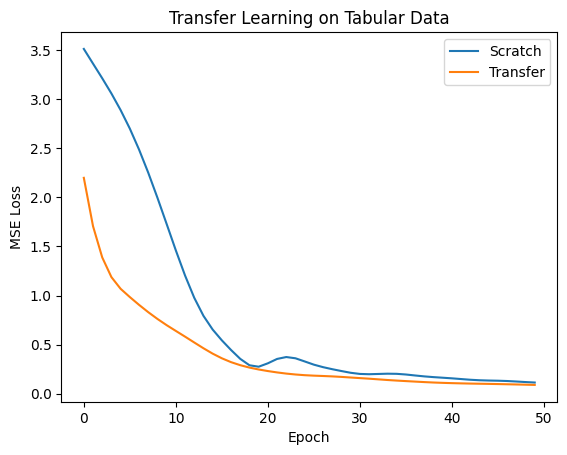

In [22]:
from re import X
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
torch.manual_seed(0)

# -------------------------
# 1. Generate synthetic data
# -------------------------
def generate_data(N=1000, task="A",n=4,sdw=0.15):
    X = torch.randn(N, n)

    if task == "A":
        y = X[:, 0]*X[:,1] + np.sin(X[:, 1])+X[:, 2] +sdw*np.random.randn(N).astype(np.float32)
    else:  # Task B
        y = X[:, 0]*X[:,1] + X[:, 1] + X[:,1] * X[:, 2]+sdw*np.random.randn(N).astype(np.float32)

    return X, y.unsqueeze(1)

n=4
NA=3000
NB=200
X_A, y_A = generate_data(NA, "A",n)
X_B_train, y_B_train = generate_data(NB, "B",n)   # small dataset
X_B_val, y_B_val = generate_data(10*NB, "B",n)
print(X_A.shape, y_A.shape)
print(X_B_train.shape, y_B_train.shape)
print(X_B_val.shape, y_B_val.shape)
# -------------------------
# 2. Model
# -------------------------
class Net(nn.Module):
    def __init__(self,n):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

# -------------------------
# 3. Training function
# -------------------------
def train(model, X, y, epochs=50, lr=0.01, verbose=False):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    losses = []

    for e in range(epochs):
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        if verbose and e%10 == 0:
          print(f"Epoch: {e} Loss: {loss.item():.4f}")
    return losses

def evaluate(model, X, y):
    with torch.no_grad():
        return nn.MSELoss()(model(X), y).item()

# -------------------------
# 4. Step 1: Train on Task A
# -------------------------
model_A = Net(n)
print("Training on Task A")
train(model_A, X_A, y_A, verbose=True)

# Save pretrained weights
pretrained_weights = model_A.state_dict()

# -------------------------
# 5. Step 2: Train on Task B (from scratch)
# -------------------------
model_scratch = Net(n)
print("Training on Task B (from scratch)")
train(model_scratch, X_B_train, y_B_train, verbose=True)

loss_scratch = evaluate(model_scratch, X_B_val, y_B_val)

# -------------------------
# 6. Step 3: Transfer learning
# -------------------------
model_transfer = Net(n)
print("Training on Task B (transfer)")
model_transfer.load_state_dict(pretrained_weights)

# Fine-tune on Task B
train(model_transfer, X_B_train, y_B_train, verbose=True)

loss_transfer = evaluate(model_transfer, X_B_val, y_B_val)

# -------------------------
# 7. Show results
# -------------------------
print("\nFinal Validation Loss:")
print(f"From Scratch:      {loss_scratch:.4f}")
print(f"Transfer Learning: {loss_transfer:.4f}")

# -------------------------
# 8. Plot convergence
# -------------------------
loss_scratch_curve = train(Net(n), X_B_train, y_B_train)
model_transfer2 = Net(n)
model_transfer2.load_state_dict(pretrained_weights)
loss_transfer_curve = train(model_transfer2, X_B_train, y_B_train)

plt.plot(loss_scratch_curve, label="Scratch")
plt.plot(loss_transfer_curve, label="Transfer")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Transfer Learning on Tabular Data")
plt.legend()
plt.show()

# Adversarial training

Training STANDARD model...
Training ADVERSARIAL model...

Test MSE:
Standard (clean):       0.0612
Adversarial (clean):    0.0465
Standard (attacked):    0.2104
Adversarial (attacked): 0.1631


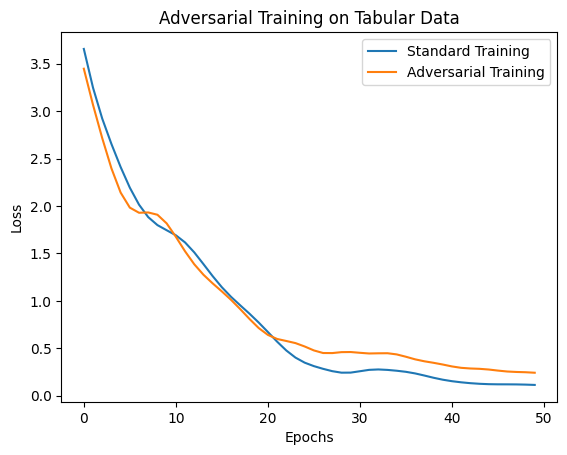

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(0)

# -------------------------
# 1. Generate tabular data
# -------------------------
N = 1000
X = torch.randn(N, 2)

# Nonlinear target
y = (X[:, 0]**2 + torch.sin(X[:, 1]) + 0.1 * torch.randn(N)).unsqueeze(1)

# Train / test split
X_train, X_test = X[:800], X[800:]
y_train, y_test = y[:800], y[800:]

# -------------------------
# 2. Simple model
# -------------------------
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

# -------------------------
# 3. FGSM attack
# -------------------------
def fgsm_attack(model, x, y, epsilon=0.1):
    x_adv = x.clone().detach().requires_grad_(True)

    criterion = nn.MSELoss()
    output = model(x_adv)
    loss = criterion(output, y)

    loss.backward()

    # perturb in gradient direction
    x_adv = x_adv + epsilon * x_adv.grad.sign()
    return x_adv.detach()

# -------------------------
# 4. Train functions
# -------------------------
def train(model, adversarial=False, epochs=50):
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()

    losses = []

    for _ in range(epochs):
        optimizer.zero_grad()

        x = X_train
        y_true = y_train

        if adversarial:
            x = fgsm_attack(model, x, y_true)

        out = model(x)
        loss = criterion(out, y_true)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return losses

def evaluate(model, x, y):
    with torch.no_grad():
        return nn.MSELoss()(model(x), y).item()

# -------------------------
# 5. Train models
# -------------------------
model_standard = Net()
model_adv = Net()

print("Training STANDARD model...")
loss_std = train(model_standard, adversarial=False)

print("Training ADVERSARIAL model...")
loss_adv = train(model_adv, adversarial=True)

# -------------------------
# 6. Evaluate robustness
# -------------------------
# clean test
clean_std = evaluate(model_standard, X_test, y_test)
clean_adv = evaluate(model_adv, X_test, y_test)

# adversarial test
X_test_adv = fgsm_attack(model_standard, X_test, y_test)

adv_std = evaluate(model_standard, X_test_adv, y_test)
adv_adv = evaluate(model_adv, X_test_adv, y_test)

# -------------------------
# 7. Results
# -------------------------
print("\nTest MSE:")
print(f"Standard (clean):       {clean_std:.4f}")
print(f"Adversarial (clean):    {clean_adv:.4f}")
print(f"Standard (attacked):    {adv_std:.4f}")
print(f"Adversarial (attacked): {adv_adv:.4f}")

# -------------------------
# 8. Plot
# -------------------------
plt.plot(loss_std, label="Standard Training")
plt.plot(loss_adv, label="Adversarial Training")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Adversarial Training on Tabular Data")
plt.legend()

plt.show()